In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder  #LabelEncoder: This class is used to encode categorical data into numerical values.
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("C:\AI_Learning\Week3\Day2\company_positions.csv")
print(df.head())


          Position  Level  Salary
0   Region Manager      6   15000
1          Manager      4    8000
2   Senior Partner      8   30000
3          C-level      9   50000
4  Country Manager      5   11000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  100 non-null    object
 1   Level     100 non-null    int64 
 2   Salary    100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [ ]:
#Extracting features and target variable
#  :
X = df.iloc[:,1:2].values  #iloc-integer location which will select rows and columns by index. Here, we are selecting all rows and the second column (index 1) as features. why not only 1 beacuse 2 keep it as a 2d  which a model expects.
y = df.iloc[:,2].values

In [7]:
#Label Encoding for categorical target variable
label_encoder = LabelEncoder()   #will convert categorical data to numerical data

for col in df.select_dtypes(include=['object']).columns:  #object in python defines string or txt which is a datatype defined here
    df[col] = label_encoder.fit_transform(df[col])  #will select 1 column and fit will convert unique value and transform will convert txt to number

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
regressor = RandomForestRegressor(
    n_estimators=100, #no ofdecision tree we want to create
    random_state=42, #ensures reproducibility by setting a fixed seed for random number generation.
    oob_score=True #use out of bag samples to estimate model perfomance
)

regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
#calcualting oob score
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.9999942029294443
Mean Squared Error: 1500.0
R-squared: 0.9999964140783285


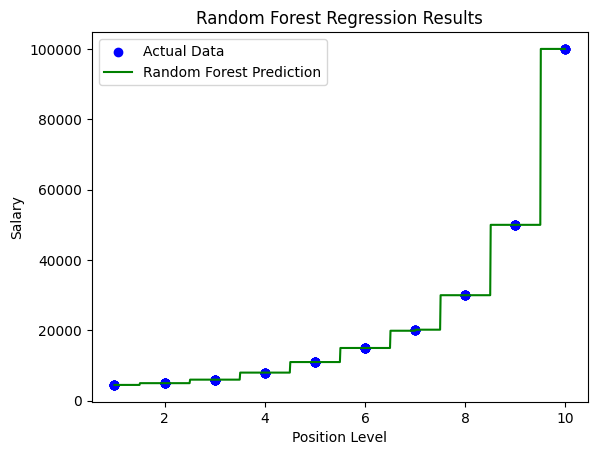

In [14]:
# Create a smooth grid for plotting
X_grid = np.arange(
    X.min(),
    X.max(),
    0.01
).reshape(-1, 1)

# Plot original data
plt.scatter(X, y, color='blue', label="Actual Data")

# Plot Random Forest predictions
plt.plot(
    X_grid,
    regressor.predict(X_grid),
    color='green',
    label="Random Forest Prediction"
)

plt.title("Random Forest Regression Results")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()


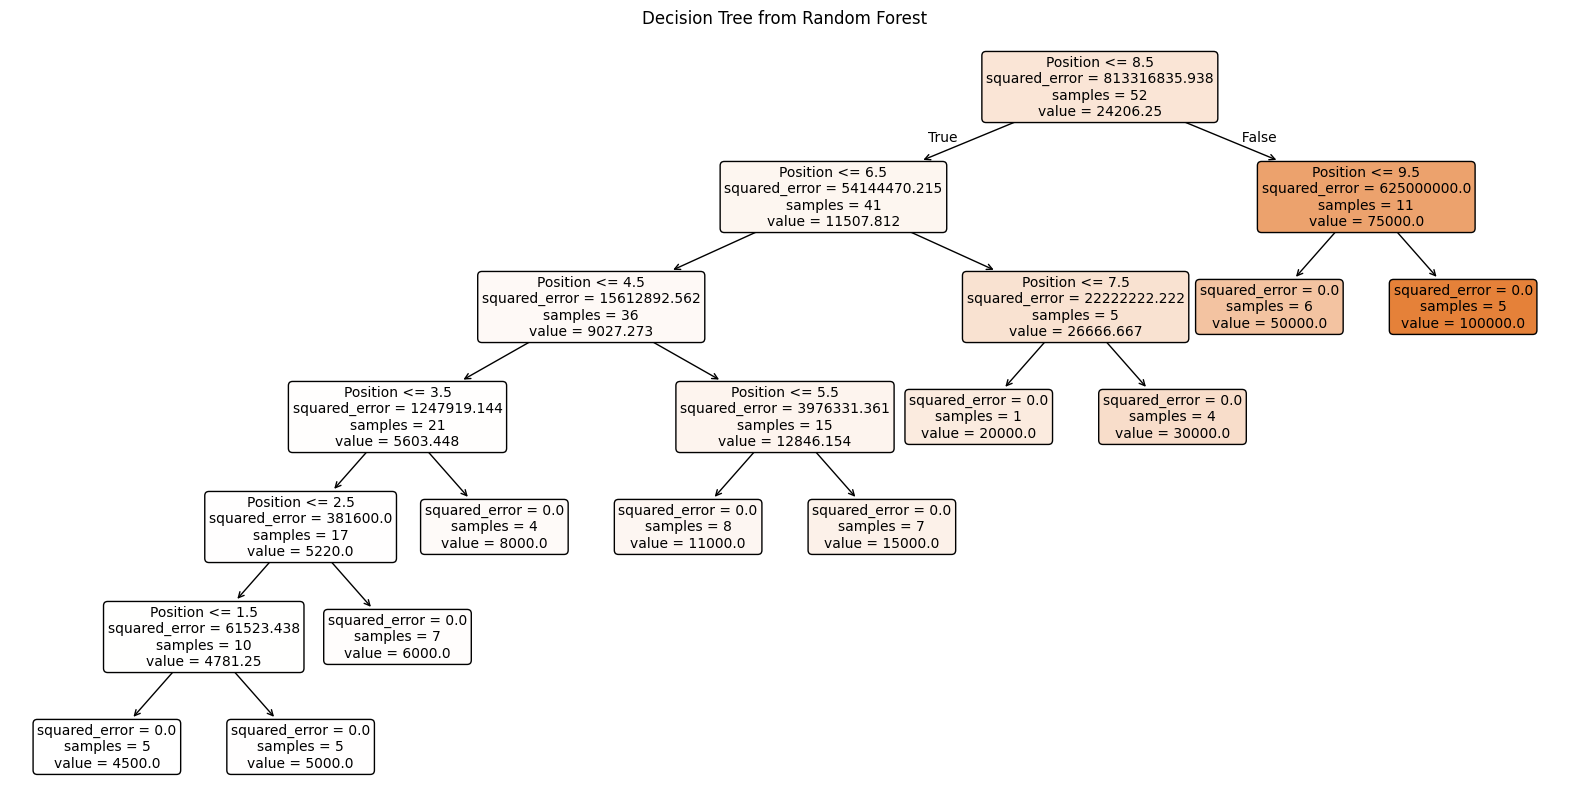

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = regressor.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()